Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']
Training Data: (455, 30)
Testing Data: (114, 30)

CatBoost Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



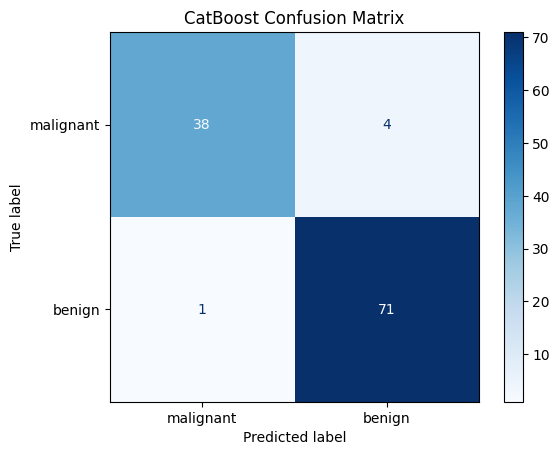


Top 10 Important Features:
                 Feature  Importance
21         worst texture   10.929108
23            worst area    9.714333
22       worst perimeter    9.018776
27  worst concave points    8.936300
7    mean concave points    6.355140
24      worst smoothness    5.181378
1           mean texture    4.515133
20          worst radius    4.459069
18        symmetry error    3.519624
10          radius error    3.174667


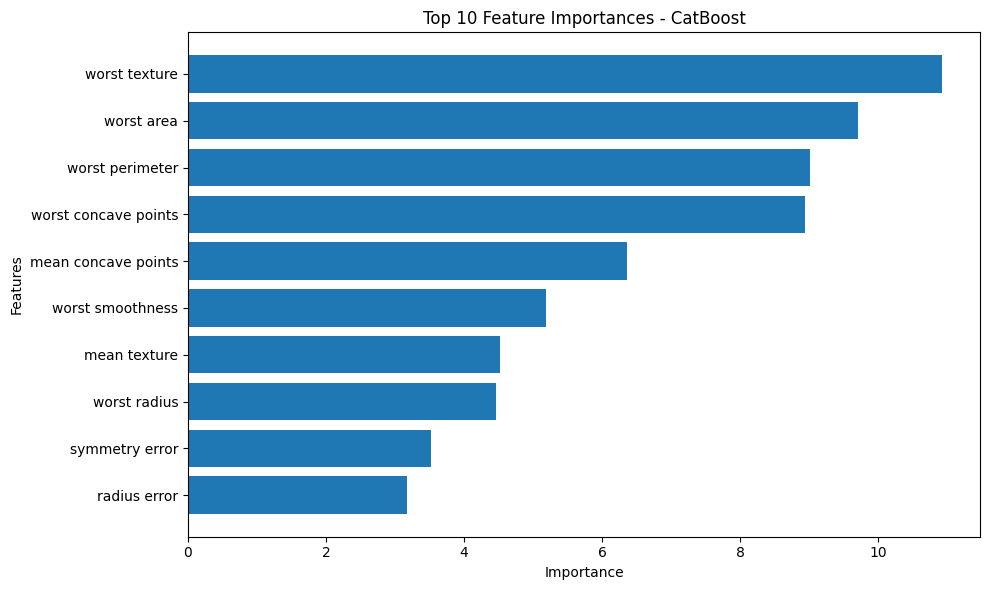

In [5]:
# Step 1: Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Step 2: Load the dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

# Step 3: Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Step 4: Create the CatBoost classifier

model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=False
)

# Step 5: Train the model

model.fit(X_train, y_train)

# Step 6: Make predictions

y_pred = model.predict(X_test).ravel()

# Step 7: Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print("\nCatBoost Accuracy:", accuracy)
print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# Step 8: Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")
plt.title("CatBoost Confusion Matrix")
plt.show()

# Step 9: Display feature importance

feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

# Step 10: Plot top 10 important features

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(10)[::-1],
    importance_df["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances - CatBoost")
plt.tight_layout()
plt.show()